In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q opencv-python-headless

import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from glob import glob

import torch
import torch.nn as nn
from torchvision import transforms as T
from torch.utils.data import Dataset, DataLoader
import torchvision

seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f'Currently using "{device}" device.')
if device == "cpu":
    print("GPU가 감지되지 않았습니다. 런타임 > 런타임 유형 변경 > 하드웨어 가속기를 GPU로 설정해주세요.")

Currently using "cuda" device.


In [4]:
# ====== 하이퍼파라미터 ======
batch_size = 24
image_size = 256
num_classes = 1
epochs = 15
best_model_filename = 'esw_seg_model_best.pt'  # 검증 손실 기준 best 모델 파일명
valid_ratio = 0.15  # train 폴더 중 검증용으로 뗄 비율

# ====== 데이터셋 루트 경로 (본인 환경에 맞게 이 한 줄만 수정하면 됩니다) ======
# 주의: Colab에서 Drive를 마운트하면 보통 '/content/drive/MyDrive/...' 아래에 파일이 생깁니다.
root_dir = r'/content/drive/MyDrive/esw_seg_model/input/crack_segmentation_dataset/'

# 데이터셋 파일 확장자 (jpg / png 등 실제 파일에 맞게 수정)
img_ext = '*.jpg'
mask_ext = '*.jpg'

# train/ , test/ 폴더 경로는 root_dir 기준으로 자동 계산됩니다.
train_images_dir = os.path.join(root_dir, 'train', 'images')
train_masks_dir  = os.path.join(root_dir, 'train', 'masks')
test_images_dir  = os.path.join(root_dir, 'test', 'images')
test_masks_dir   = os.path.join(root_dir, 'test', 'masks')

# ---- 경로 존재 여부 먼저 확인 (오타/마운트 문제를 빨리 잡기 위함) ----
for _name, _p in [
    ('train_images_dir', train_images_dir),
    ('train_masks_dir', train_masks_dir),
    ('test_images_dir', test_images_dir),
    ('test_masks_dir', test_masks_dir),
]:
    if not os.path.isdir(_p):
        raise FileNotFoundError(
            f"{_name} 경로가 존재하지 않습니다: {_p}\n"
            f"'!ls \"{root_dir}\"' 등으로 실제 폴더 구조를 확인한 뒤 root_dir을 다시 설정하세요."
        )


In [5]:
def build_df(images_dir, masks_dir, img_ext='*.jpg', mask_ext='*.jpg'):
    """images_dir / masks_dir 안의 파일을 파일명(확장자 제외) 기준으로 매칭해 DataFrame으로 만듭니다.
    단순히 정렬 순서로 매칭하지 않고 실제 파일명을 비교하므로, 두 폴더의 파일 개수가
    다르거나 일부만 매칭되는 경우에도 안전하게 동작합니다."""
    image_paths = sorted(glob(os.path.join(images_dir, img_ext)))
    mask_paths_all = sorted(glob(os.path.join(masks_dir, mask_ext)))
    mask_lookup = {os.path.splitext(os.path.basename(p))[0]: p for p in mask_paths_all}

    matched_images, matched_masks, missing = [], [], []
    for img_p in image_paths:
        stem = os.path.splitext(os.path.basename(img_p))[0]
        if stem in mask_lookup:
            matched_images.append(img_p)
            matched_masks.append(mask_lookup[stem])
        else:
            missing.append(img_p)

    if missing:
        print(f'[경고] {images_dir} 중 {len(missing)}개 이미지에 매칭되는 마스크가 없어 제외합니다. '
              f'(예: {[os.path.basename(p) for p in missing[:3]]})')

    return pd.DataFrame({'images': matched_images, 'masks': matched_masks})


train_full_df = build_df(train_images_dir, train_masks_dir, img_ext, mask_ext)
test_df = build_df(test_images_dir, test_masks_dir, img_ext, mask_ext)

assert len(train_full_df) > 0, (
    f"{train_images_dir} 에서 매칭되는 이미지-마스크 쌍을 찾지 못했습니다. "
    f"img_ext('{img_ext}')가 실제 파일 확장자와 일치하는지 확인하세요."
)
assert len(test_df) > 0, (
    f"{test_images_dir} 에서 매칭되는 이미지-마스크 쌍을 찾지 못했습니다. "
    f"img_ext('{img_ext}')가 실제 파일 확장자와 일치하는지 확인하세요."
)

print(f'train 폴더: {len(train_full_df)}개의 이미지-마스크 쌍')
print(f'test 폴더 : {len(test_df)}개의 이미지-마스크 쌍')
train_full_df.sample(min(2, len(train_full_df)))


train 폴더: 9603개의 이미지-마스크 쌍
test 폴더 : 1695개의 이미지-마스크 쌍


,images,masks
1318,/content/drive/MyDrive/esw_seg_model/input/cra...,/content/drive/MyDrive/esw_seg_model/input/cra...
9506,/content/drive/MyDrive/esw_seg_model/input/cra...,/content/drive/MyDrive/esw_seg_model/input/cra...


In [6]:
# ====== Train / Valid 분할 (Test는 데이터셋에 이미 분리되어 있으므로 그대로 사용) ======
train, valid = train_test_split(train_full_df, test_size=valid_ratio, shuffle=True, random_state=seed)
test = test_df.reset_index(drop=True)

print(f'Train size: {len(train)}, validation size: {len(valid)}, test size: {len(test)}')


Train size: 8162, validation size: 1441, test size: 1695


In [7]:
train_transforms = T.Compose([
    T.ToPILImage(),
    T.Resize((image_size, image_size)),
    # 필요하다면 여기에 색상/밝기 등 augmentation을 추가하세요.
    T.ToTensor()
])


In [8]:
class WallCrackDataset(Dataset):
    """벽면 균열 이미지 / 바이너리 마스크 쌍을 로드하는 Dataset."""

    def __init__(self, dataset, transforms=train_transforms):
        self.dataset = dataset.reset_index(drop=True)
        self.transforms = transforms

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, ix):
        row = self.dataset.loc[ix].squeeze()
        image_path = row['images']
        mask_path = row['masks']

        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image_tensor = self.transforms(image).float()

        mask = cv2.imread(mask_path)
        mask = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)
        mask = cv2.resize(mask, (image_size, image_size))
        _, mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

        # 균열=1, 배경=0 이 되도록 0~1 범위로 정규화
        mask_tensor = torch.as_tensor(mask[None], dtype=torch.float32) / 255.

        return image_tensor, mask_tensor

    def collate_fn(self, batch):
        images, masks = tuple(zip(*batch))
        images = [img[None] for img in images]
        masks = [msk[None] for msk in masks]
        images, masks = [torch.cat(i).to(device) for i in [images, masks]]
        return images, masks


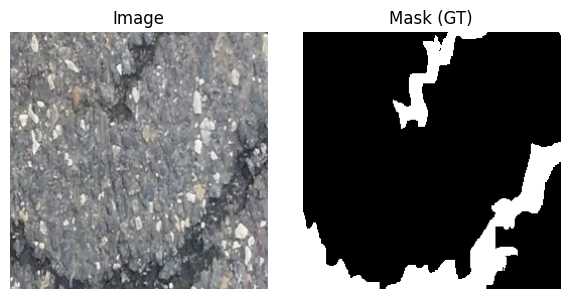

In [9]:
# 데이터가 잘 로드되는지 샘플 확인
_sample_ds = WallCrackDataset(train)
plt.figure(figsize=(6, 3))
plt.subplot(121); plt.title('Image'); plt.axis('off')
plt.imshow(_sample_ds[0][0].cpu().numpy().transpose(1, 2, 0))
plt.subplot(122); plt.title('Mask (GT)'); plt.axis('off')
plt.imshow(_sample_ds[0][1][0].cpu().numpy(), cmap='gray')
plt.tight_layout()
plt.show()


In [10]:
train_dataset = WallCrackDataset(train)
valid_dataset = WallCrackDataset(valid)

train_dataloader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True,
    collate_fn=train_dataset.collate_fn, drop_last=True
)
valid_dataloader = DataLoader(
    valid_dataset, batch_size=batch_size, shuffle=False,
    collate_fn=valid_dataset.collate_fn, drop_last=True
)


In [11]:
from torchvision.models.segmentation.deeplabv3 import DeepLabHead

def get_model(output_channels=1, unfreeze=True):
    model = torchvision.models.segmentation.deeplabv3_resnet101(pretrained=True, progress=True)
    for param in model.parameters():
        param.requires_grad = unfreeze
    model.classifier = DeepLabHead(2048, output_channels)
    return model.to(device)

model = get_model(output_channels=num_classes)


Downloading: "https://download.pytorch.org/models/deeplabv3_resnet101_coco-586e9e4e.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet101_coco-586e9e4e.pth


100%|██████████| 233M/233M [00:01<00:00, 184MB/s]


In [12]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        probs = probs.reshape(probs.size(0), -1)
        targets = targets.reshape(targets.size(0), -1)
        intersection = (probs * targets).sum(dim=1)
        union = probs.sum(dim=1) + targets.sum(dim=1)
        dice = (2. * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice.mean()


class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()
        self.bce_weight = bce_weight

    def forward(self, logits, targets):
        return self.bce_weight * self.bce(logits, targets) + (1 - self.bce_weight) * self.dice(logits, targets)


criterion = BCEDiceLoss(bce_weight=0.5)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, min_lr=1e-6, factor=0.1)


In [13]:
@torch.no_grad()
def visualize_prediction(model, dataset, epoch=None):
    idx = np.random.randint(len(dataset))
    dataset = dataset.reset_index(drop=True)
    row = dataset.loc[idx].squeeze()

    image = cv2.imread(row['images'])
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image_tensor = train_transforms(image).unsqueeze(0).to(device)

    mask = cv2.imread(row['masks'])
    mask = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)
    mask = cv2.resize(mask, (image_size, image_size))
    _, mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

    model.eval()
    logits = model(image_tensor)['out']
    pred = torch.sigmoid(logits)[0, 0].cpu().numpy()

    title = f'Epoch {epoch} 예측 결과' if epoch is not None else '예측 결과'
    plt.figure(figsize=(9, 3))
    plt.suptitle(title)
    plt.subplot(131); plt.title('Original'); plt.imshow(image); plt.axis('off')
    plt.subplot(132); plt.title('GT Mask'); plt.imshow(mask, cmap='gray'); plt.axis('off')
    plt.subplot(133); plt.title('Predicted Mask'); plt.imshow(pred, cmap='gray'); plt.axis('off')
    plt.tight_layout()
    plt.show()


In [14]:
# 매 epoch 체크포인트를 저장할 디렉토리
output_dir = os.path.expanduser('/content/drive/MyDrive/esw_seg_model/output/')
os.makedirs(output_dir, exist_ok=True)
print(f'모델 저장 디렉토리: {output_dir}')


모델 저장 디렉토리: /content/drive/MyDrive/esw_seg_model/output/


In [15]:
def train_one_batch(batch, model, criterion, optimizer):
    images, masks = batch
    optimizer.zero_grad()
    output = model(images)['out']
    loss = criterion(output, masks)
    loss.backward()
    optimizer.step()
    return loss.item()


@torch.no_grad()
def validate_one_batch(batch, model, criterion):
    images, masks = batch
    output = model(images)['out']
    loss = criterion(output, masks)
    return loss.item()


In [ ]:
train_losses, valid_losses = [], []
best_valid_loss = np.inf

for epoch in range(epochs):
    print(f'Epoch {epoch + 1}/{epochs}')
    epoch_train_losses, epoch_valid_losses = [], []

    # ---- Train ----
    model.train()
    for batch in tqdm(train_dataloader, leave=False, desc='Train'):
        batch_train_loss = train_one_batch(batch, model, criterion, optimizer)
        epoch_train_losses.append(batch_train_loss)
    epoch_train_loss = float(np.mean(epoch_train_losses))
    train_losses.append(epoch_train_loss)
    print(f'Train loss: {epoch_train_loss:.4f}')

    # ---- Validate ----
    model.eval()
    for batch in tqdm(valid_dataloader, leave=False, desc='Valid'):
        batch_valid_loss = validate_one_batch(batch, model, criterion)
        epoch_valid_losses.append(batch_valid_loss)
    epoch_valid_loss = float(np.mean(epoch_valid_losses))
    valid_losses.append(epoch_valid_loss)
    print(f'Valid loss: {epoch_valid_loss:.4f}')
    print('-' * 50)

    # ---- 예측 결과 시각화 (선택) ----
    visualize_prediction(model, test, epoch=epoch + 1)

    # ====== 요청하신 부분: 매 epoch마다 모델 저장 ======
    epoch_ckpt_path = os.path.join(output_dir, f'esw_seg_model_epoch_{epoch + 1}.pt')
    torch.save(model.state_dict(), epoch_ckpt_path)
    print(f'저장 완료: {epoch_ckpt_path}')

    # ---- (선택) 검증 손실 기준 best 모델 별도 저장 ----
    if epoch_valid_loss < best_valid_loss:
        best_valid_loss = epoch_valid_loss
        best_ckpt_path = os.path.join(output_dir, best_model_filename)
        torch.save(model.state_dict(), best_ckpt_path)
        print(f'Best 모델 갱신: {best_ckpt_path} (valid loss: {best_valid_loss:.4f})')

    scheduler.step(epoch_valid_loss)


Epoch 1/15


Train:   0%|          | 0/340 [00:00<?, ?it/s]